---

# SundaLife

*Visualisasi Data Kemiskinan Jawa Barat 2021-2025*

---

## Kelompok 01 - IF4061 Visualisasi Data

- 13523004 - Razi Rachman Widyadhana
- 13523006 - William Andrian Dharma T
- 13523086 - Bob Kunanda
- 13523103 - Steven Owen Liauw
- 13523109 - Haegen Quinston

---

## Daftar Isi

1. [**Pendahuluan**](#1)
2. [**Inisialisasi**](#2)
3. [**Persiapan Data**](#3)
4. [**Transformasi Data**](#4)
5. [**Grafik 1: Tren Kemiskinan Pulau Jawa 2021-2025**](#5)
6. [**Grafik 2: Peta Sebaran Kemiskinan Jawa Barat**](#6)
7. [**Grafik 3: Korelasi Kemiskinan dan Pengangguran**](#7)
8. [**Grafik 4: Kota-Kota Anomali**](#8)


---

# Pendahuluan <a name="1"></a>

---

Jawa Barat merupakan provinsi dengan jumlah penduduk terbesar di Indonesia, namun menyimpan disparitas kemiskinan yang signifikan antarwilayah. Pola kemiskinan di tingkat kabupaten/kota memperlihatkan dinamika yang berbeda dari gambaran agregat provinsi, dan perlu ditelusuri secara lebih rinci.

Analisis ini menelusuri empat pertanyaan: bagaimana posisi Jawa Barat dibandingkan provinsi lain di Pulau Jawa selama 2021-2025, di mana kemiskinan paling terkonsentrasi di tingkat kabupaten/kota, seberapa kuat hubungan antara kemiskinan dan pengangguran, serta wilayah mana yang memperlihatkan pola berbeda dari mayoritas.

---

# Inisialisasi <a name="2"></a>

---

`geopandas` digunakan untuk membaca batas wilayah dari file `Jabar_By_Kab.geojson` dan memplot peta *choropleth*. Seluruh impor diletakkan dalam satu sel.

In [1]:
# %pip install geopandas --quiet

In [2]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats

%matplotlib inline

DATA_DIR   = '../data/'
RAW_DIR    = DATA_DIR + 'raw/'
CLEAN_DIR  = DATA_DIR + 'clean/'
OUTPUT_DIR = '../docs/output/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'figure.facecolor': 'none',
    'axes.facecolor':   'none',
})

---

# Persiapan Data <a name="3"></a>

---

Tahap ini membaca data mentah dari BPS dan menghasilkan dua file bersih di `data/clean/`. Struktur bagian ini mengikuti urutan langkah 2.2 hingga 2.5 pada laporan, yaitu *Data Examination*, *Data Cleaning*, kemudian *Data Transformation*.

## Data Examination

Pratinjau format mentah setiap sumber data sebelum diproses.

**Gambar 2.2.1** Pratinjau Baris Pertama File `Persentase Penduduk Miskin (P0) Menurut Provinsi dan Daerah, 2025.csv` Mentah.

In [3]:
pd.read_csv(RAW_DIR + 'Persentase Penduduk Miskin (P0) Menurut Provinsi dan Daerah, 2025.csv', nrows=7)

,38 Provinsi,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,NaN,Persentase Penduduk Miskin (P0) Menurut Provin...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Perkotaan,NaN,NaN,Perdesaan,NaN,NaN,Jumlah,NaN,NaN
2,NaN,2025,NaN,NaN,2025,NaN,NaN,2025,NaN,NaN
3,NaN,Semester 1 (Maret),Semester 2 (September),Tahunan,Semester 1 (Maret),Semester 2 (September),Tahunan,Semester 1 (Maret),Semester 2 (September),Tahunan
4,ACEH,8.54,8.15,-,14.44,14.51,-,12.33,12.22,-
5,SUMATERA UTARA,7.1,7.16,-,7.71,7.35,-,7.36,7.24,-
6,SUMATERA BARAT,3.91,3.75,-,6.93,7.03,-,5.35,5.31,-


**Gambar 2.2.2** Pratinjau File Indikator BPS Kabupaten/Kota Jawa Barat.

In [4]:
pd.read_csv(RAW_DIR + 'Persentase Penduduk Miskin Menurut Kabupaten_Kota di Jawa Barat, 2025.csv', header=None)

,0,1
0,Kabupaten/Kota,NaN
1,NaN,Persentase Penduduk Miskin Menurut Kabupaten/K...
2,NaN,2025
3,Provinsi Jawa Barat,7.02
4,Bogor,6.26
5,Sukabumi,6.41
6,Cianjur,9.82
7,Bandung,6.04
8,Garut,9.39
9,Tasikmalaya,10.15


**Gambar 2.2.3** Pemeriksaan Nilai Unik Atribut Nama Wilayah pada `Jabar_By_Kab.geojson`.

In [5]:
gdf_preview = gpd.read_file(CLEAN_DIR + 'Jabar_By_Kab.geojson')
gdf_preview[['PROVINSI', 'KABKOT']].head(10)

,PROVINSI,KABKOT
0,JAWA BARAT,BOGOR
1,JAWA BARAT,SUKABUMI
2,JAWA BARAT,CIANJUR
3,JAWA BARAT,BANDUNG
4,JAWA BARAT,GARUT
5,JAWA BARAT,TASIKMALAYA
6,JAWA BARAT,CIAMIS
7,JAWA BARAT,PANGANDARAN
8,JAWA BARAT,KUNINGAN
9,JAWA BARAT,CIREBON


## Data Cleaning & Quality Improvement

Data P0 difilter untuk enam provinsi Pulau Jawa dan dipilih nilai Semester 2 (dengan *fallback* ke Semester 1 apabila Semester 2 tidak tersedia). Data jabar dihapus baris agregat provinsinya dan kolom numeriknya dikonversi ke tipe float.

In [6]:
YEARS = [2021, 2022, 2023, 2024, 2025]
JAWA  = [
    'JAWA BARAT', 'JAWA TENGAH', 'JAWA TIMUR',
    'DKI JAKARTA', 'BANTEN', 'DI YOGYAKARTA',
]

processed = []
for year in YEARS:
    df = pd.read_csv(RAW_DIR + f'Persentase Penduduk Miskin (P0) Menurut Provinsi dan Daerah, {year}.csv', skiprows=4)
    df = df.iloc[:, [0, 1, 2]]
    df.columns = ['Provinsi', 'S1', 'S2']
    df['Provinsi'] = df['Provinsi'].str.strip()
    df = df[df['Provinsi'].isin(JAWA)].copy()
    df['S1'] = pd.to_numeric(df['S1'], errors='coerce')
    df['S2'] = pd.to_numeric(df['S2'], errors='coerce')
    df[str(year)] = df['S2'].fillna(df['S1'])
    processed.append(df[['Provinsi', str(year)]])

p0_jawa = processed[0]
for df in processed[1:]:
    p0_jawa = p0_jawa.merge(df, on='Provinsi', how='outer')

p0_jawa.to_csv(CLEAN_DIR + 'p0_jawa_2021-2025.csv', index=False, encoding='utf-8')

**Gambar 2.4.1** Dataset P0 Setelah Filter Enam Provinsi Pulau Jawa.

In [7]:
df_g241 = pd.read_csv(RAW_DIR + 'Persentase Penduduk Miskin (P0) Menurut Provinsi dan Daerah, 2025.csv', skiprows=4).iloc[:, [0,1,2]]
df_g241.columns = ['Provinsi', 'S1', 'S2']
df_g241['Provinsi'] = df_g241['Provinsi'].str.strip()
df_g241[df_g241['Provinsi'].isin(JAWA)]

,Provinsi,S1,S2
10,DKI JAKARTA,4.28,4.03
11,JAWA BARAT,6.76,6.66
12,JAWA TENGAH,9.10,8.99
13,DI YOGYAKARTA,10.16,9.99
14,JAWA TIMUR,7.00,6.93
15,BANTEN,5.58,5.35


In [8]:
def clean_bps(path, col):
    df = pd.read_csv(path, header=None).iloc[:, :2]
    df.columns = ['region', col]
    df['region'] = df['region'].astype(str).str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.dropna(subset=['region', col])
    return df[~df['region'].str.contains('Provinsi', na=False)]

jabar_raw = (
    clean_bps(
        RAW_DIR + 'Persentase Penduduk Miskin Menurut Kabupaten_Kota di Jawa Barat, 2025.csv',
        'poverty_rate',
    )
    .merge(clean_bps(
        RAW_DIR + 'Tingkat Pengangguran Terbuka Kabupaten_Kota, 2025.csv',
        'unemployment_rate',
    ), on='region')
    .merge(clean_bps(
        RAW_DIR + 'Garis Kemiskinan Menurut Kabupaten_Kota, 2025.csv',
        'poverty_level',
    ), on='region')
)

jabar_raw.to_csv(CLEAN_DIR + 'jabar_2025.csv', index=False, encoding='utf-8')

**Gambar 2.4.2** Dataset jabar Setelah Penghapusan Baris Tidak Relevan (27 baris tersisa).

In [9]:
jabar_raw

,region,poverty_rate,unemployment_rate,poverty_level
0,nan,2025.00,2025.00,2025.0
1,Bogor,6.26,7.69,531412.0
2,Sukabumi,6.41,7.23,431785.0
3,Cianjur,9.82,6.17,482562.0
4,Bandung,6.04,6.68,468974.0
5,Garut,9.39,6.54,407191.0
6,Tasikmalaya,10.15,3.69,413178.0
7,Ciamis,7.19,4.08,483644.0
8,Kuningan,10.74,7.59,435184.0
9,Cirebon,10.23,6.42,491604.0


**Gambar 2.4.3** Verifikasi Kesesuaian Nama Wilayah: Baris GeoJSON yang Tidak Cocok dengan BPS (hasil kosong mengonfirmasi seluruh nama selaras).

In [10]:
gdf_preview = gpd.read_file(CLEAN_DIR + 'Jabar_By_Kab.geojson')
gdf_preview['region_title'] = gdf_preview['KABKOT'].str.title()
jabar_regions = set(jabar_raw['region'])
gdf_preview[~gdf_preview['region_title'].isin(jabar_regions)][['KABKOT', 'region_title']]

,KABKOT,region_title


**Gambar 2.4.4** Tipe Data Dataset jabar Setelah Konversi Numerik.

In [11]:
jabar_raw.dtypes.to_frame('dtype')

,dtype
region,object
poverty_rate,float64
unemployment_rate,float64
poverty_level,float64


## Data Transformation for Analysis

Hasil pembersihan ditampilkan dalam format final yang akan digunakan untuk visualisasi.

**Gambar 2.5.1** Hasil Penggabungan Lima Tahun ke Format *Wide* (`p0_jawa_2021-2025.csv`).

In [12]:
p0_jawa

,Provinsi,2021,2022,2023,2024,2025
0,BANTEN,6.04,5.89,6.00,5.57,5.35
1,DI YOGYAKARTA,11.20,10.64,10.27,10.11,9.99
2,DKI JAKARTA,4.67,4.61,4.44,4.14,4.03
3,JAWA BARAT,7.48,7.52,7.19,6.65,6.66
4,JAWA TENGAH,10.16,10.02,9.78,8.83,8.99
5,JAWA TIMUR,7.99,7.78,7.50,6.83,6.93


**Gambar 2.5.2** Dataset jabar Hasil Penggabungan Tiga Indikator (27 baris, 4 kolom).

In [13]:
jabar_raw[['region', 'poverty_rate', 'unemployment_rate', 'poverty_level']]

,region,poverty_rate,unemployment_rate,poverty_level
0,nan,2025.00,2025.00,2025.0
1,Bogor,6.26,7.69,531412.0
2,Sukabumi,6.41,7.23,431785.0
3,Cianjur,9.82,6.17,482562.0
4,Bandung,6.04,6.68,468974.0
5,Garut,9.39,6.54,407191.0
6,Tasikmalaya,10.15,3.69,413178.0
7,Ciamis,7.19,4.08,483644.0
8,Kuningan,10.74,7.59,435184.0
9,Cirebon,10.23,6.42,491604.0


---

# Transformasi Data <a name="4"></a>

---

Nama wilayah diselaraskan agar cocok dengan atribut nama pada `Jabar_By_Kab.geojson`. Kolom `type` ditambahkan untuk membedakan Kota dan Kabupaten. Satu entri memerlukan pemetaan manual, yaitu *Bandung Barat* dalam BPS berpadanan dengan nama berbeda dalam GeoJSON.

In [14]:
p0_jawa = pd.read_csv(CLEAN_DIR + 'p0_jawa_2021-2025.csv')
jabar    = pd.read_csv(CLEAN_DIR + 'jabar_2025.csv', dtype={'region': str})

jabar = jabar.dropna(subset=['region'])
jabar['type'] = np.where(
    jabar['region'].str.startswith('Kota ', na=False), 'Kota', 'Kabupaten'
)

jabar['ratio'] = jabar['poverty_rate'] / jabar['unemployment_rate']
ANOMALI_HIGH = (
    jabar.nlargest(4, 'ratio')
    .query("region != 'Majalengka'")
    ['region'].head(3).tolist()
)
ANOMALI_LOW  = jabar.nsmallest(3, 'ratio')['region'].tolist()
ANOMALI_ALL  = ANOMALI_HIGH + ANOMALI_LOW

**Gambar 2.5.3** Pratinjau Kolom Turunan `type` dan `ratio` pada Dataset jabar.

In [15]:
jabar[['region', 'type', 'poverty_rate', 'unemployment_rate', 'poverty_level', 'ratio']]

,region,type,poverty_rate,unemployment_rate,poverty_level,ratio
1,Bogor,Kabupaten,6.26,7.69,531412.0,0.814044
2,Sukabumi,Kabupaten,6.41,7.23,431785.0,0.886584
3,Cianjur,Kabupaten,9.82,6.17,482562.0,1.591572
4,Bandung,Kabupaten,6.04,6.68,468974.0,0.904192
5,Garut,Kabupaten,9.39,6.54,407191.0,1.435780
6,Tasikmalaya,Kabupaten,10.15,3.69,413178.0,2.750678
7,Ciamis,Kabupaten,7.19,4.08,483644.0,1.762255
8,Kuningan,Kabupaten,10.74,7.59,435184.0,1.415020
9,Cirebon,Kabupaten,10.23,6.42,491604.0,1.593458
10,Majalengka,Kabupaten,10.31,3.62,566574.0,2.848066


---

# Grafik 1: Tren Kemiskinan Pulau Jawa 2021-2025 <a name="5"></a>

---

Grafik garis ini memperlihatkan perkembangan persentase penduduk miskin di enam provinsi Pulau Jawa dari 2021 hingga 2025. Jawa Barat disorot dengan warna merah dan ketebalan garis yang lebih besar, sedangkan provinsi lain ditampilkan dalam abu-abu sebagai konteks.

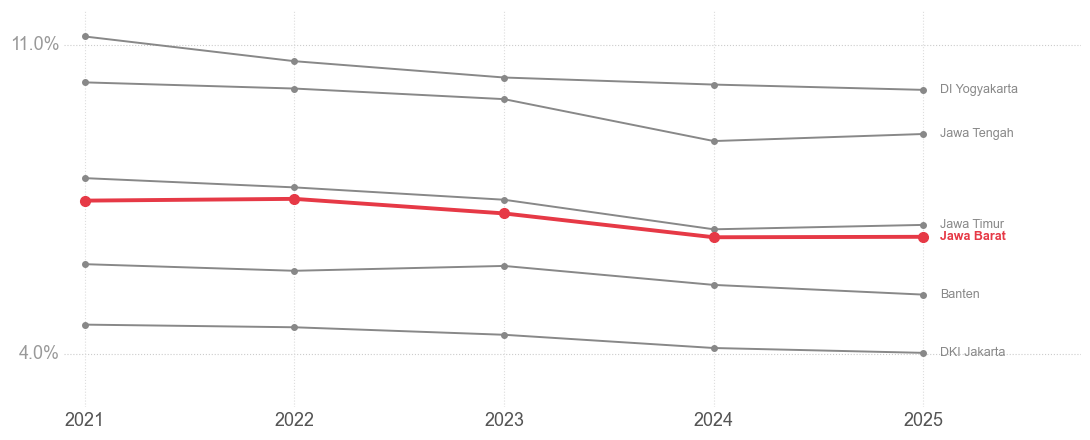

In [16]:
df_plot = p0_jawa.set_index('Provinsi').T
df_plot.index = df_plot.index.astype(int)

PROV_STYLE = {
    'JAWA BARAT'    : ('Jawa Barat',    '#E63946', 2.8, 7, 5),
    'DI YOGYAKARTA' : ('DI Yogyakarta', '#888888', 1.4, 4, 2),
    'JAWA TENGAH'   : ('Jawa Tengah',   '#888888', 1.4, 4, 2),
    'JAWA TIMUR'    : ('Jawa Timur',    '#888888', 1.4, 4, 2),
    'BANTEN'        : ('Banten',        '#888888', 1.4, 4, 2),
    'DKI JAKARTA'   : ('DKI Jakarta',   '#888888', 1.4, 4, 2),
}

fig, ax = plt.subplots(figsize=(11, 4.5))

for prov, (label, color, lw, ms, zo) in PROV_STYLE.items():
    is_jabar = prov == 'JAWA BARAT'
    ax.plot(df_plot.index, df_plot[prov],
            color=color, linewidth=lw, marker='o',
            markersize=ms, zorder=zo)
    ax.text(
        df_plot.index[-1] + 0.08, df_plot[prov].iloc[-1],
        label, color=color, fontsize=9, va='center',
        fontweight='bold' if is_jabar else 'normal',
    )

for ref_y in [4.0, 11.0]:
    ax.axhline(ref_y, color='#CCCCCC', linewidth=0.8, linestyle=':', zorder=0)
    ax.text(df_plot.index[0] - 0.12, ref_y,
            f'{ref_y:.1f}%', fontsize=13, color='#999999', va='center', ha='right')

for year in df_plot.index:
    ax.axvline(year, color='#DDDDDD', linewidth=0.8, linestyle=':', zorder=0)

ax.set_xlim(df_plot.index[0] - 0.1, df_plot.index[-1] + 0.75)
ax.set_ylim(2.8, 11.8)
ax.set_xticks(df_plot.index)
ax.set_xticklabels([str(y) for y in df_plot.index], fontsize=13, color='#555555')
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', left=False, labelleft=False)
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'g1_tren.png', dpi=150, bbox_inches='tight', facecolor='none')
plt.show()

#### Wawasan

> Secara keseluruhan, seluruh provinsi di Pulau Jawa mencatat penurunan angka kemiskinan dari 2021 ke 2025, meskipun beberapa provinsi mengalami fluktuasi di tengah periode. Jawa Tengah dan Jawa Timur bahkan mencatat sedikit kenaikan di tahun 2025, mengindikasikan bahwa pemulihan pasca 2021 tidak bersifat linier. Jawa Barat berada di posisi menengah dengan kisaran 6,65-7,52%, di bawah DI Yogyakarta dan Jawa Tengah yang konsisten di atas 8%, tetapi lebih tinggi dibandingkan DKI Jakarta dan Banten.

---

# Grafik 2: Peta Sebaran Kemiskinan Jawa Barat 2025 <a name="6"></a>

---

Peta *choropleth* ini menampilkan tingkat kemiskinan di setiap kabupaten/kota Jawa Barat pada 2025. Batas wilayah menggunakan GeoJSON komunitas Jawa Barat yang dibaca dengan `geopandas`. Wilayah tanpa padanan data (Waduk Cirata merupakan badan air) ditampilkan dalam abu-abu.

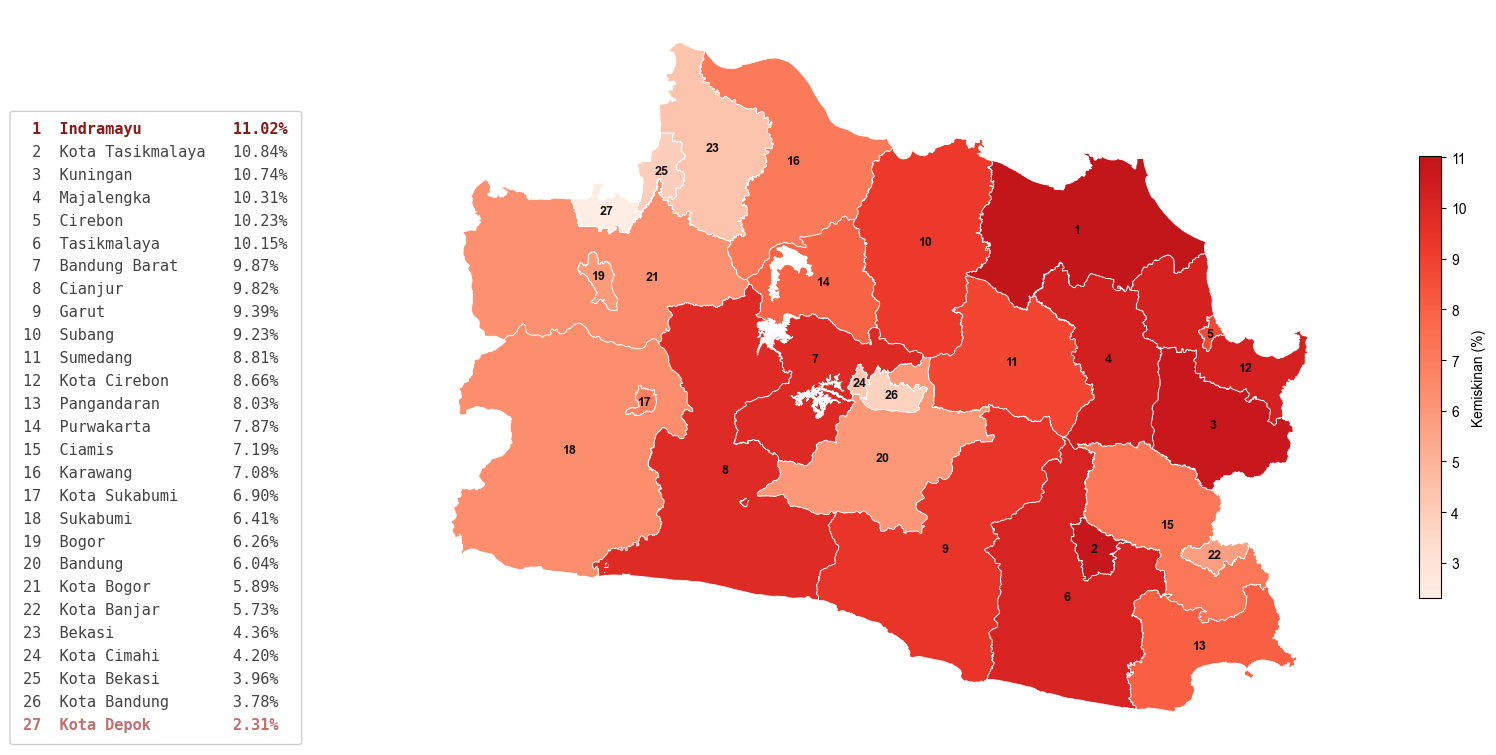

In [17]:
from matplotlib.colors import LinearSegmentedColormap

gdf_jabar = gpd.read_file(CLEAN_DIR + 'Jabar_By_Kab.geojson').copy()
gdf_jabar['region'] = gdf_jabar['KABKOT'].str.title()

gdf_jabar = gdf_jabar.merge(
    jabar[['region', 'type', 'poverty_rate']],
    on='region', how='left',
)

ranked = (
    jabar[['region', 'poverty_rate']]
    .sort_values('poverty_rate', ascending=False)
    .reset_index(drop=True)
)
ranked['num'] = ranked.index + 1
gdf_jabar = gdf_jabar.merge(ranked[['region', 'num']], on='region', how='left')

reds_light = LinearSegmentedColormap.from_list(
    'Reds_light', plt.cm.Reds(np.linspace(0.05, 0.78, 256))
)

fig, ax_map = plt.subplots(figsize=(18, 8))
fig.subplots_adjust(left=0.16, right=0.92, top=0.96, bottom=0.04)

gdf_jabar.plot(
    column='poverty_rate',
    cmap=reds_light,
    linewidth=0.6,
    edgecolor='white',
    legend=True,
    legend_kwds={'label': 'Kemiskinan (%)', 'orientation': 'vertical', 'shrink': 0.6},
    missing_kwds={'color': '#DDDDDD', 'label': 'Tidak ada data'},
    ax=ax_map,
)

pos = {}
for _, row in gdf_jabar.iterrows():
    if pd.notna(row.get('num')):
        c = row.geometry.centroid
        pos[int(row['num'])] = (c.x, c.y, row.geometry.area)

NUDGE = {
    19: ( 0.025, -0.02),
    21: ( 0.15,   0.01),
    12: ( 0.1,   -0.1 ),
     7: ( 0.0,    0.08),
}

for num, (x, y, _) in pos.items():
    dx, dy = NUDGE.get(num, (0, 0))
    ax_map.annotate(
        str(num), xy=(x + dx, y + dy),
        ha='center', va='center',
        fontsize=9, fontweight='bold', color='#111111',
    )

ax_map.axis('off')

from matplotlib.patches import FancyBboxPatch
lh = 11 * 1.5 / (8 * 72)
x0, y0 = 0.03, 0.82
n_lines = len(ranked)
total_h = n_lines * lh
rect = FancyBboxPatch(
    (x0 - 0.005, y0 - total_h - 0.004),
    0.158, total_h + 0.014,
    transform=fig.transFigure,
    boxstyle='round,pad=0.002',
    facecolor='white', edgecolor='#CCCCCC',
    linewidth=1, alpha=0.92, zorder=2,
)
fig.add_artist(rect)
for i, (_, r) in enumerate(ranked.iterrows()):
    num = int(r['num'])
    line = f"{num:2d}  {r['region']:<18} {r['poverty_rate']:.2f}%"
    c  = '#8B1A1A' if num == 1 else ('#C0706F' if num == 27 else '#444444')
    fw = 'bold' if num in (1, 27) else 'normal'
    fig.text(x0, y0 - i * lh, line, fontsize=11, fontfamily='monospace',
             color=c, va='top', fontweight=fw, zorder=3)

plt.savefig(OUTPUT_DIR + 'g2_peta.png', dpi=150, bbox_inches='tight', pad_inches=0.2, facecolor='none')
plt.show()

#### Wawasan

> Kemiskinan di Jawa Barat terkonsentrasi di bagian selatan dan timur. Kabupaten Indramayu, Kuningan, Majalengka, dan Tasikmalaya memperlihatkan angka kemiskinan tertinggi yang melampaui 10%. Sebaliknya, kota-kota di koridor utara seperti Kota Depok, Kota Bekasi, dan Kota Bandung mencatat tingkat kemiskinan terendah di bawah 5%, mencerminkan konsentrasi aktivitas ekonomi formal di kawasan tersebut.

---

# Grafik 3: Korelasi Kemiskinan dan Pengangguran 2025 <a name="7"></a>

---

Grafik pencar ini menguji hubungan antara persentase penduduk miskin dan tingkat pengangguran terbuka (TPT) di 27 kabupaten/kota Jawa Barat pada 2025. Kota dan Kabupaten dibedakan dengan warna berbeda, dan garis regresi linier ditampilkan untuk masing-masing kelompok.

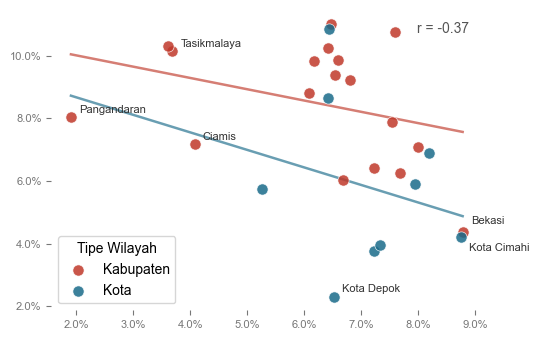

In [18]:
COLOR_MAP = {'Kota': '#1A6B8A', 'Kabupaten': '#C0392B'}

fig, ax = plt.subplots(figsize=(5.5, 3.5))

for t, grp in jabar.groupby('type'):
    ax.scatter(
        grp['unemployment_rate'], grp['poverty_rate'],
        color=COLOR_MAP[t], s=65, alpha=0.85,
        edgecolors='white', linewidths=0.5,
        label=t, zorder=3,
    )
    slope, intercept, *_ = stats.linregress(
        grp['unemployment_rate'], grp['poverty_rate']
    )
    xl = np.linspace(jabar['unemployment_rate'].min(),
                     jabar['unemployment_rate'].max(), 100)
    ax.plot(xl, slope * xl + intercept,
            color=COLOR_MAP[t], linewidth=1.8, alpha=0.65)

LABEL_OFFSET = {
    'Bekasi':     (6, 6),
    'Kota Cimahi': (6, -10),
}
for _, row in jabar[jabar['region'].isin(ANOMALI_ALL)].iterrows():
    dx, dy = LABEL_OFFSET.get(row['region'], (6, 3))
    ax.annotate(
        row['region'],
        xy=(row['unemployment_rate'], row['poverty_rate']),
        xytext=(dx, dy), textcoords='offset points',
        fontsize=8, color='#333333',
    )

r, _ = stats.pearsonr(jabar['unemployment_rate'], jabar['poverty_rate'])
ax.text(0.97, 0.96, f'r = {r:.2f}', transform=ax.transAxes,
        fontsize=10, va='top', ha='right', color='#555555')

ax.legend(title='Tipe Wilayah', frameon=True, fontsize=10,
          loc='lower left', borderaxespad=0.5)
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f%%'))
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f%%'))
ax.tick_params(axis='x', labelsize=8, colors='#777777')
ax.tick_params(axis='y', labelsize=8, colors='#777777')
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'g3_scatter.png', dpi=150, bbox_inches='tight', facecolor='none')
plt.show()

#### Wawasan

> Korelasi antara kemiskinan dan pengangguran di Jawa Barat lemah dan negatif (r = -0.37), menunjukkan bahwa tingginya pengangguran tidak selalu sejalan dengan tingginya kemiskinan. Kabupaten Pangandaran, Tasikmalaya, dan Ciamis memiliki tingkat pengangguran yang sangat rendah tetapi angka kemiskinan tinggi di Jawa Barat, mengindikasikan bahwa pekerjaan yang tersedia di kawasan tersebut belum mampu mengangkat daya beli masyarakat.

---

# Grafik 4: Kota-Kota Anomali Jawa Barat 2025 <a name="8"></a>

---

Untuk menguji apakah garis kemiskinan menjelaskan anomali, nilai garis kemiskinan keenam wilayah anomali dibandingkan melalui batang horizontal. Apabila garis kemiskinan menjadi penyebab anomali, wilayah dengan TPT rendah (merah) seharusnya memiliki batang pendek karena standar subsisten di wilayah tersebut rendah, bukan karena upah yang tinggi, sementara wilayah dengan TPT tinggi (hijau) seharusnya memiliki batang yang panjang.

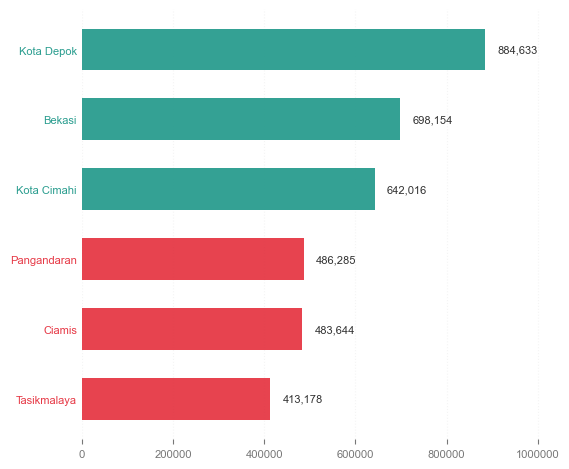

In [19]:
anomali = jabar[jabar['region'].isin(ANOMALI_ALL)].copy()
anomali = anomali.sort_values('poverty_level', ascending=False).reset_index(drop=True)

C_HIGH = '#E63946'
C_LOW  = '#2A9D8F'

# assign color per region: ANOMALI_HIGH -> C_HIGH, ANOMALI_LOW -> C_LOW
colors = [C_HIGH if r in ANOMALI_HIGH else C_LOW for r in anomali['region']]

fig, ax = plt.subplots(figsize=(5.8, 4.8))

y = np.arange(len(anomali))
ax.barh(y, anomali['poverty_level'], height=0.6,
        color=colors, alpha=0.95, zorder=3)

# add horizontal gap between bar end and label text
x_offset = anomali['poverty_level'].max() * 0.03
for i, (_, row) in enumerate(anomali.iterrows()):
    value = row['poverty_level']
    txt = f'{value:,.0f}'
    ax.text(value + x_offset, i, txt,
            ha='left', va='center', fontsize=8, color='#333333', clip_on=False)

ax.invert_yaxis()
ax.set_yticks(y)
ax.set_yticklabels(anomali['region'], fontsize=8)
# color ytick labels to match bars
for lbl, region in zip(ax.get_yticklabels(), anomali['region']):
    lbl.set_color(C_HIGH if region in ANOMALI_HIGH else C_LOW)

ax.set_xlim(0, anomali['poverty_level'].max() * 1.15)

ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
ax.tick_params(axis='x', labelsize=8, colors='#777777')
ax.tick_params(axis='y', length=0)
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.grid(axis='x', linestyle=':', alpha=0.3, color='#DDDDDD', zorder=0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'g4_barchart.png', dpi=150, bbox_inches='tight', facecolor='none')
plt.show()

#### Wawasan

> Tiga wilayah rasio tinggi (merah) memiliki TPT di peringkat terbawah tetapi garis kemiskinan yang hanya berada di kisaran menengah ke bawah. Batang garis kemiskinan mereka tidak cukup panjang untuk menunjukkan biaya hidup yang sangat tinggi, sehingga hipotesis biaya hidup tidak terkonfirmasi. Kemiskinan tinggi di sini bukan karena standar subsisten yang mahal, melainkan karena upah sektor pertanian memang rendah secara absolut.

> Tiga wilayah rasio rendah (hijau) memiliki garis kemiskinan di peringkat tertinggi, dengan batang garis kemiskinan yang panjang terutama pada Kota Depok. Pola ini mengonfirmasi bahwa standar biaya hidup perkotaan yang lebih tinggi berkorelasi dengan rendahnya kemiskinan meski penganggurannya tinggi.